STEP 1. 데이터 및 모델 불러오기
✓ 모델 및 SHAP 값 불러오기 완료
  Test 환자 수: 233명
  피처 수     : 14개

STEP 2. 고위험/저위험 환자 선택
고위험 그룹 (상위 10%): 24명
저위험 그룹 (하위 10%): 24명

대표 환자:
  고위험 환자 (idx=48): 위험점수 = 793.288
  저위험 환자 (idx=126): 위험점수 = 22.270

[ 고위험 대표 환자 특성 ]
  Age                 : 77
  Sex                 : 0
  Prior_cancer        : 0
  Grade_G2            : 0
  Grade_G3            : 0
  Grade_G4            : 1
  Site_BrainNOS       : 1
  Site_Cerebrum       : 0
  Site_Other          : 0
  Era_After2005       : 0
  Era_Before2005      : 1
  Tx_Single           : 0
  Tx_Standard         : 1
  Tx_None             : 0

[ 저위험 대표 환자 특성 ]
  Age                 : 28
  Sex                 : 1
  Prior_cancer        : 0
  Grade_G2            : 1
  Grade_G3            : 0
  Grade_G4            : 0
  Site_BrainNOS       : 0
  Site_Cerebrum       : 1
  Site_Other          : 0
  Era_After2005       : 1
  Era_Before2005      : 0
  Tx_Single           : 0
  Tx_Standard         : 1
  Tx_None             : 0

STEP 3. SHAP 

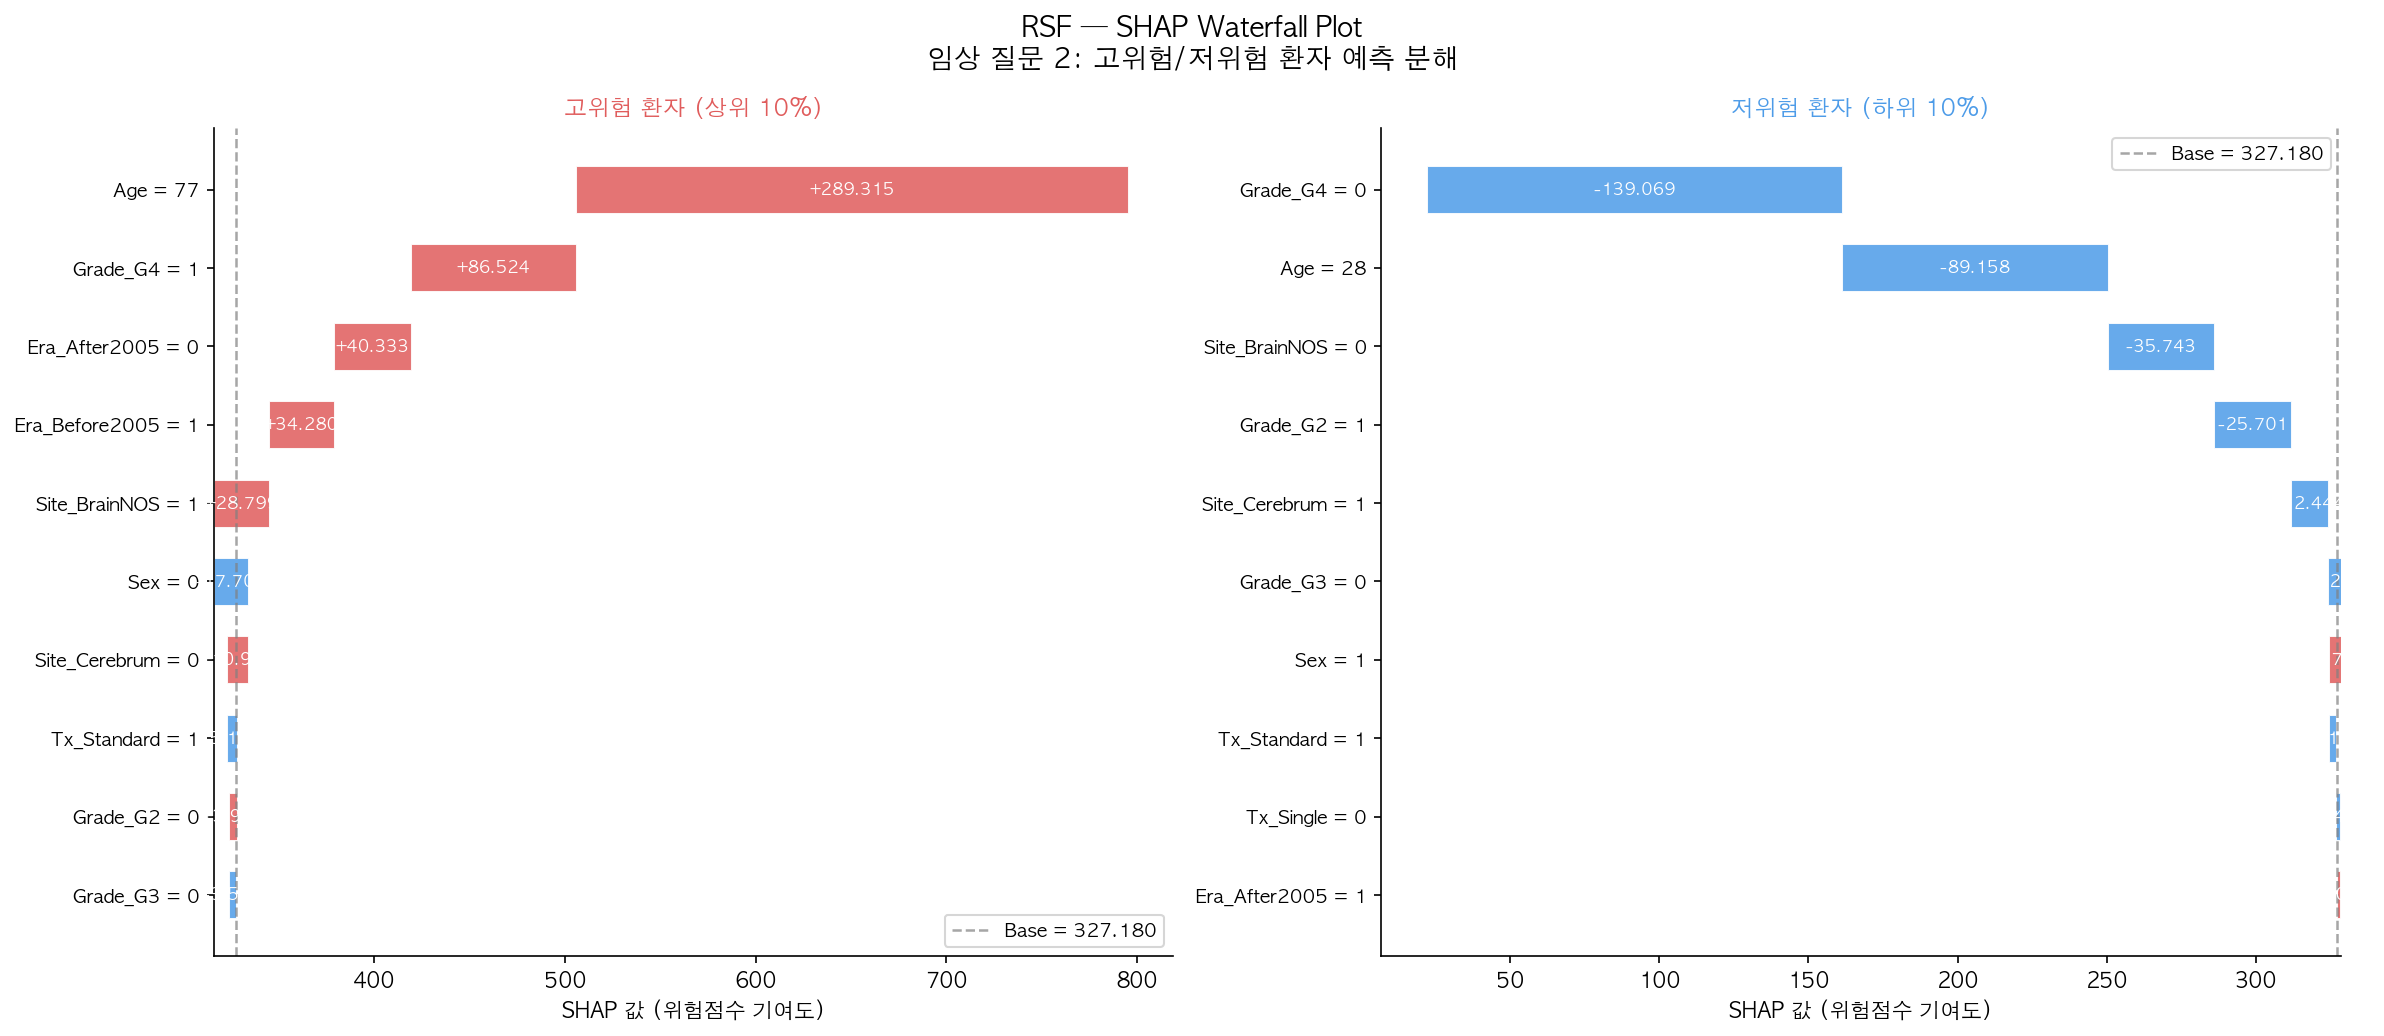

✓ fig_waterfall_rsf.png 저장 완료


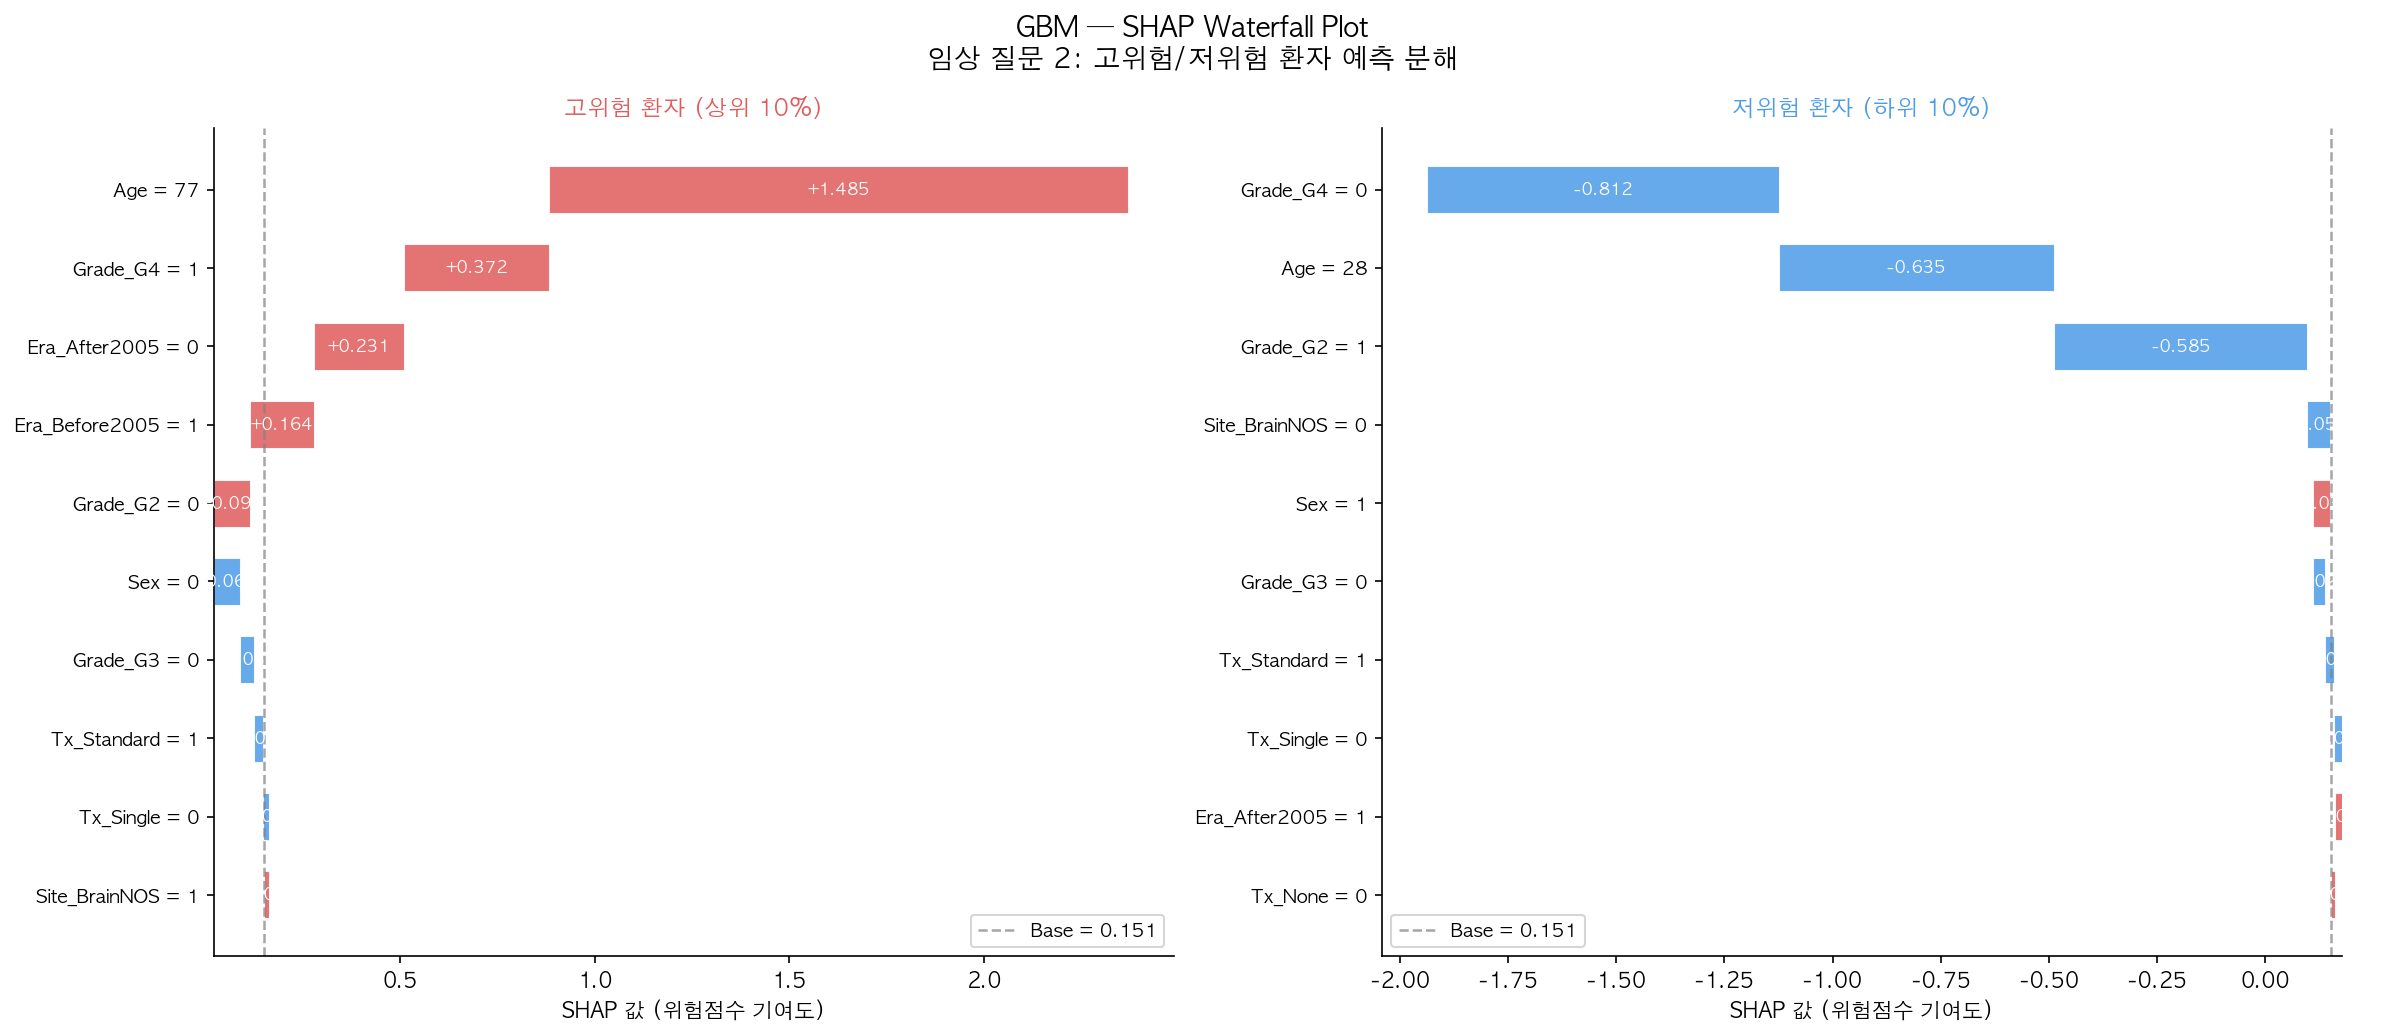

✓ fig_waterfall_gbm.png 저장 완료

STEP 4. c-ICE Plot
변수 변화에 따른 개별 환자 반응 곡선
고위험/저위험 그룹 비교

[ Age c-ICE ]


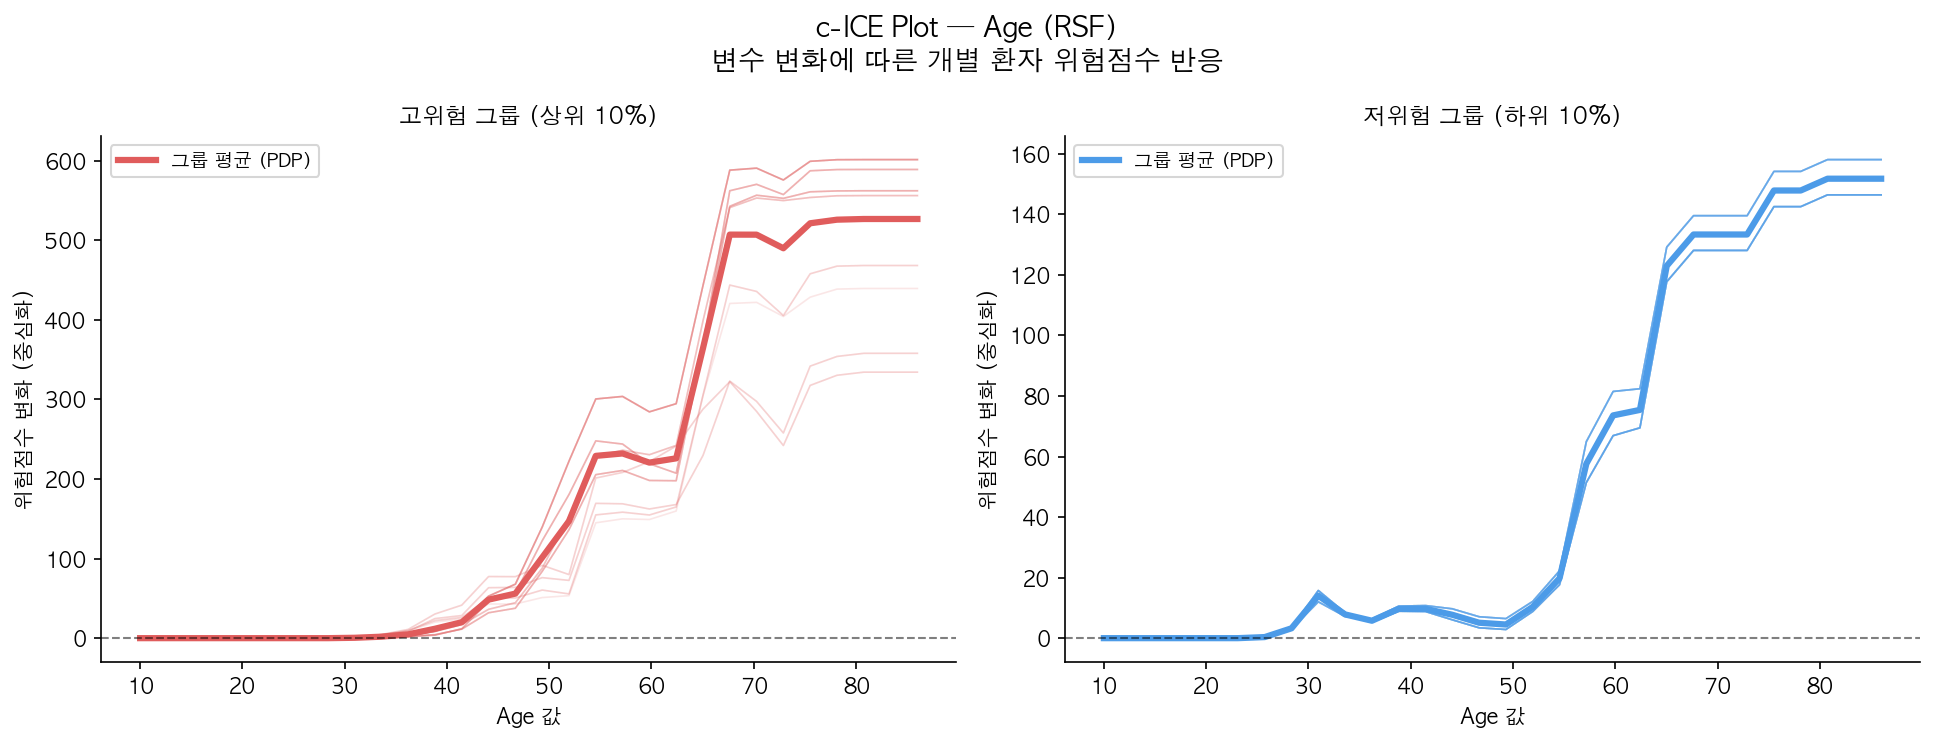

✓ fig_cice_age_rsf.png 저장 완료


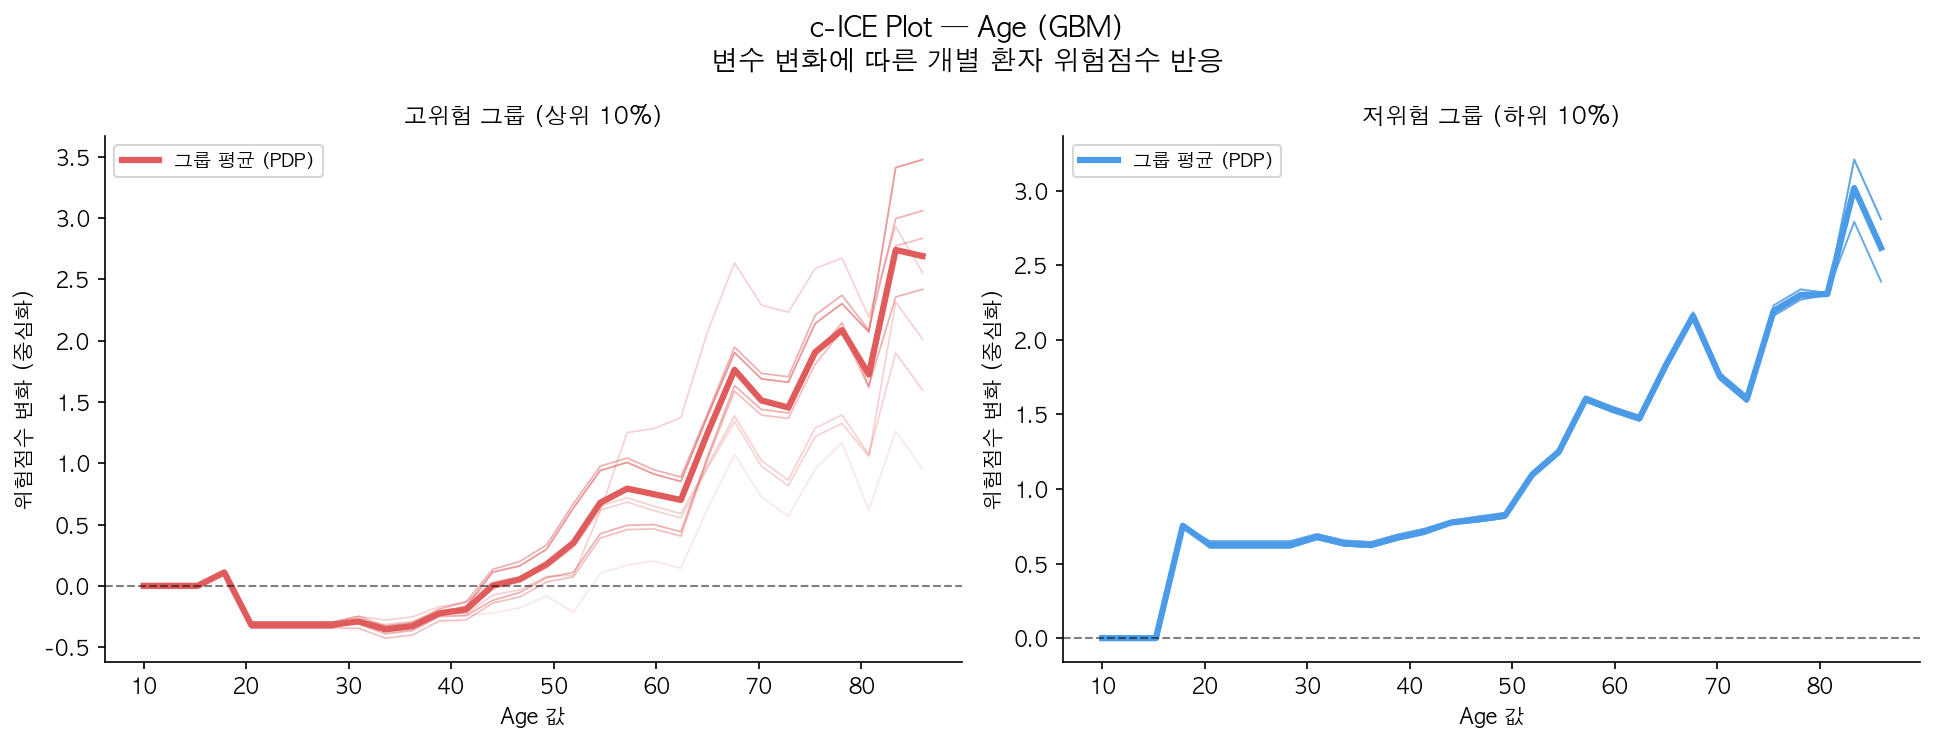

✓ fig_cice_age_gbm.png 저장 완료

[ Grade_G4 c-ICE ]


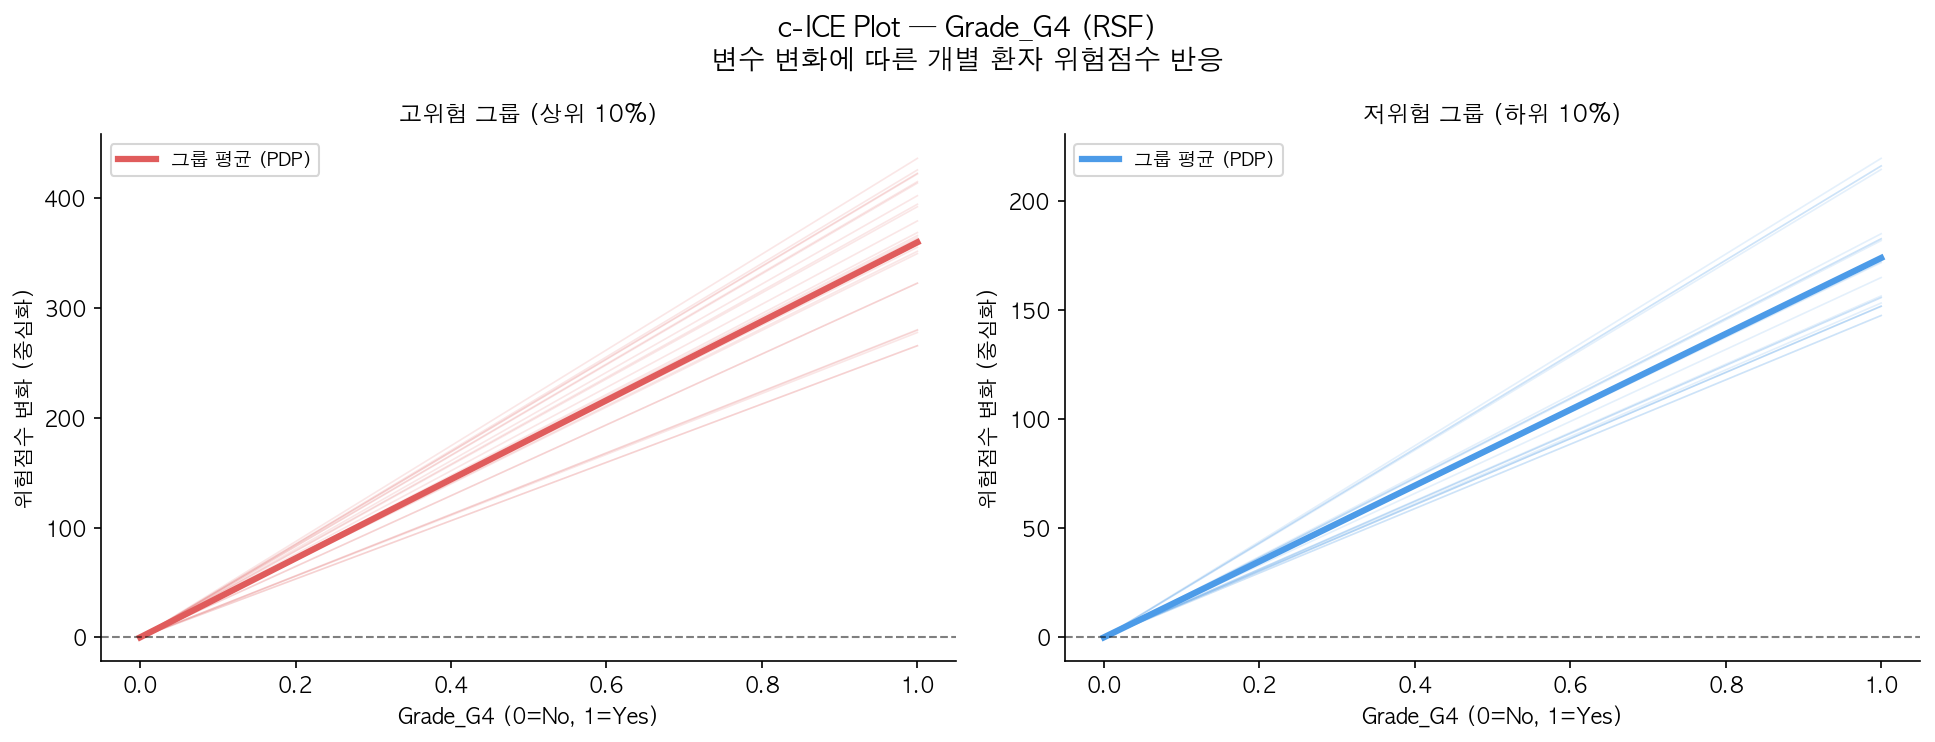

✓ fig_cice_grade_rsf.png 저장 완료


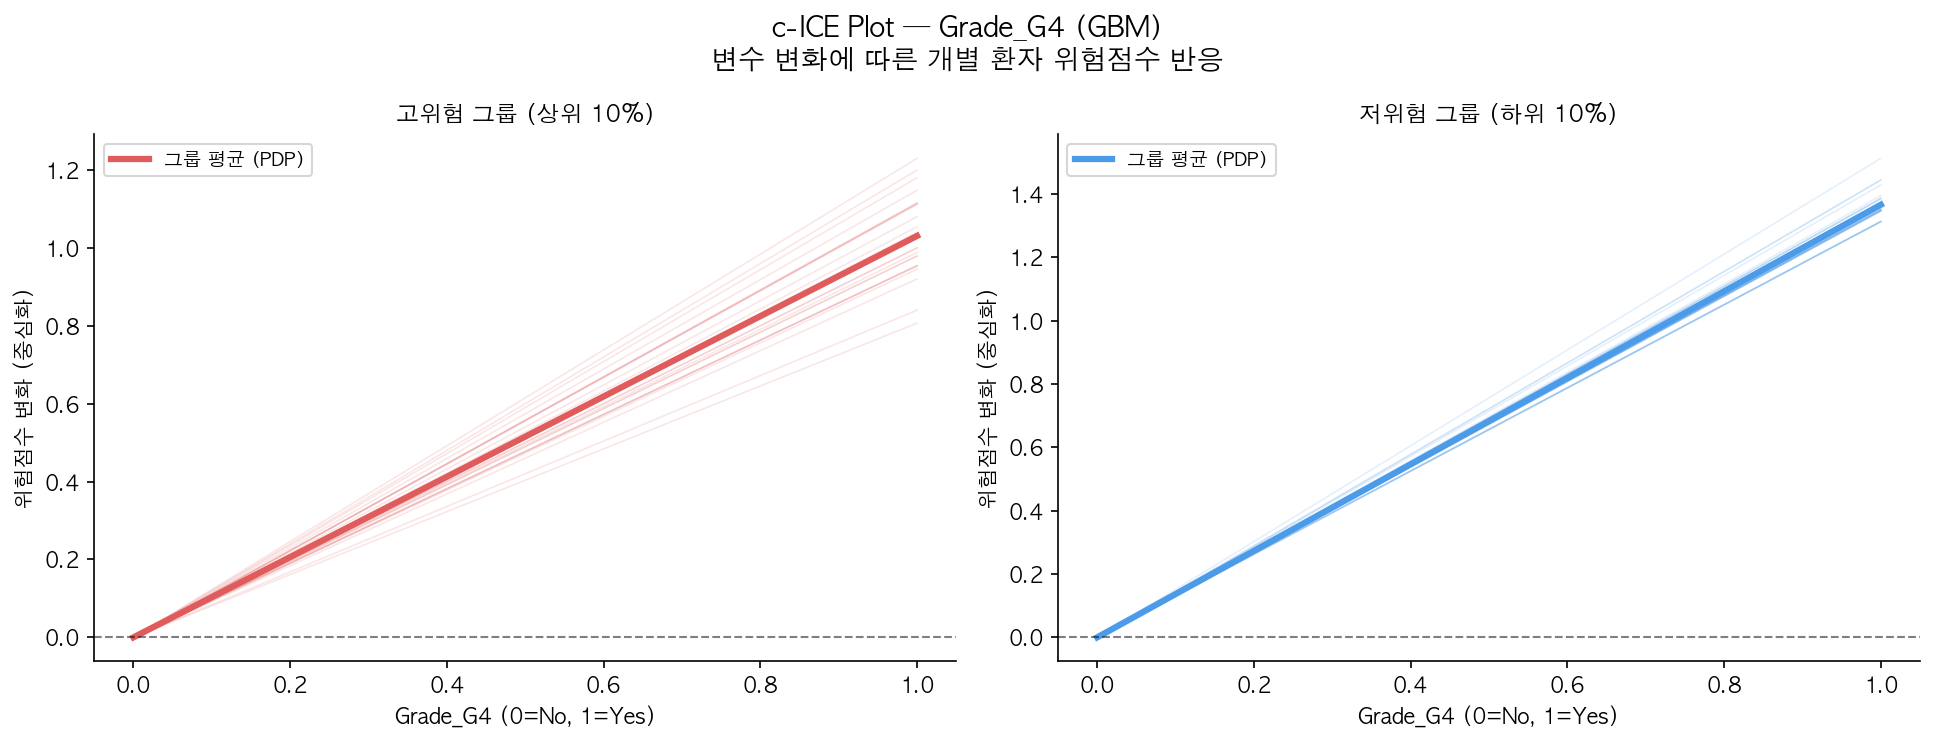

✓ fig_cice_grade_gbm.png 저장 완료

STEP 5. 결과 저장
✓ local_xai.pkl 저장 완료
  → NB 07 SurvSHAP(t)에서 바로 불러와 사용

NB 06 완료 — Local XAI 요약

[ 임상 질문 2: 고위험/저위험 환자 차이 ]
  고위험 대표 환자 위험점수 : 793.288
  저위험 대표 환자 위험점수 : 22.270
  위험점수 차이             : 771.017

  고위험 환자 Grade_G4 : 1
  저위험 환자 Grade_G4 : 0

→ 다음: NB 07 SurvSHAP(t) 시간 의존적 설명


In [2]:
# ============================================================
# NB 06. Local XAI — Waterfall + c-ICE
# Brain Tumor Survival Analysis — Explainable AI
#
# 임상 질문 2: 고위험/저위험 환자의 예측 차이는?
#
# STEP 1. 데이터 및 모델 불러오기
# STEP 2. 고위험/저위험 환자 선택
# STEP 3. SHAP Waterfall Plot (개별 환자 설명)
# STEP 4. c-ICE Plot (개별 반응 곡선)
# STEP 5. 결과 저장
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

import shap

plt.rcParams.update({
    'font.family'      : 'AppleGothic',
    'axes.unicode_minus': False,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

OUTPUT_DIR = "./outputs/"
MODEL_DIR  = "./outputs/models/"
SEED       = 42
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)
np.random.seed(SEED)

# ============================================================
# STEP 1. 데이터 및 모델 불러오기
# ============================================================

print("="*55)
print("STEP 1. 데이터 및 모델 불러오기")
print("="*55)

ml_data      = joblib.load(MODEL_DIR + "ml_models.pkl")
global_xai   = joblib.load(MODEL_DIR + "global_xai.pkl")

rsf_best     = ml_data['rsf_best']
gbm_best     = ml_data['gbm_best']
ML_FEATURES  = ml_data['ml_features']
X_train      = ml_data['X_train']
X_test       = ml_data['X_test']
y_test       = ml_data['y_test']
y_train      = ml_data['y_train']
times        = ml_data['times']
X_background = ml_data['X_background']

shap_rsf     = global_xai['shap_rsf']
shap_gbm     = global_xai['shap_gbm']

print(f"✓ 모델 및 SHAP 값 불러오기 완료")
print(f"  Test 환자 수: {len(X_test):,}명")
print(f"  피처 수     : {len(ML_FEATURES)}개")

# ============================================================
# STEP 2. 고위험/저위험 환자 선택
# ============================================================

print("\n" + "="*55)
print("STEP 2. 고위험/저위험 환자 선택")
print("="*55)

# RSF 위험점수 기준으로 환자 분류
risk_scores = rsf_best.predict(X_test)

# 상위 10% = 고위험, 하위 10% = 저위험
high_thresh = np.percentile(risk_scores, 90)
low_thresh  = np.percentile(risk_scores, 10)

high_risk_idx = np.where(risk_scores >= high_thresh)[0]
low_risk_idx  = np.where(risk_scores <= low_thresh)[0]

# 대표 환자 선택 — 각 그룹에서 중앙값에 가장 가까운 환자
def select_representative(indices, scores):
    """그룹 내 중앙 위험점수에 가장 가까운 환자 선택"""
    group_scores = scores[indices]
    median_score = np.median(group_scores)
    closest_idx  = indices[
        np.argmin(np.abs(group_scores - median_score))
    ]
    return closest_idx

high_rep_idx = select_representative(high_risk_idx, risk_scores)
low_rep_idx  = select_representative(low_risk_idx,  risk_scores)

print(f"고위험 그룹 (상위 10%): {len(high_risk_idx)}명")
print(f"저위험 그룹 (하위 10%): {len(low_risk_idx)}명")
print(f"\n대표 환자:")
print(f"  고위험 환자 (idx={high_rep_idx}): "
      f"위험점수 = {risk_scores[high_rep_idx]:.3f}")
print(f"  저위험 환자 (idx={low_rep_idx}): "
      f"위험점수 = {risk_scores[low_rep_idx]:.3f}")

# 대표 환자 특성 출력
print(f"\n[ 고위험 대표 환자 특성 ]")
high_patient = X_test.iloc[high_rep_idx]
for feat in ML_FEATURES:
    print(f"  {feat:20s}: {high_patient[feat]:.0f}")

print(f"\n[ 저위험 대표 환자 특성 ]")
low_patient = X_test.iloc[low_rep_idx]
for feat in ML_FEATURES:
    print(f"  {feat:20s}: {low_patient[feat]:.0f}")

# ============================================================
# STEP 3. SHAP Waterfall Plot
# ============================================================
# 개별 환자의 예측을 변수별로 분해
# "이 환자의 위험점수가 높은/낮은 이유"

print("\n" + "="*55)
print("STEP 3. SHAP Waterfall Plot")
print("="*55)
print("임상 질문 2: 고위험/저위험 환자의 예측 차이는?")

def plot_waterfall_pair(shap_vals, X_df, high_idx, low_idx,
                        model_name, fname):
    """
    고위험 / 저위험 환자 Waterfall Plot 나란히
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(
        f"{model_name} — SHAP Waterfall Plot\n"
        f"임상 질문 2: 고위험/저위험 환자 예측 분해",
        fontsize=13, fontweight='bold'
    )

    for ax, idx, label, color in zip(
        axes,
        [high_idx, low_idx],
        ['고위험 환자 (상위 10%)', '저위험 환자 (하위 10%)'],
        ['#E05C5C', '#4C9BE8']
    ):
        # SHAP 값 추출
        sv      = shap_vals.values[idx]
        base    = float(shap_vals.base_values[idx]) \
                  if hasattr(shap_vals, 'base_values') \
                  else 0.0
        feat_v  = X_df.iloc[idx].values

        # 상위 10개 변수만 표시
        top_n   = min(10, len(ML_FEATURES))
        order   = np.argsort(np.abs(sv))[::-1][:top_n]
        sv_top  = sv[order]
        fn_top  = [ML_FEATURES[i] for i in order]
        fv_top  = feat_v[order]

        # Waterfall 계산
        cumsum  = base + np.cumsum(sv_top[::-1])
        starts  = np.concatenate([[base], cumsum[:-1]])
        sv_plot = sv_top[::-1]
        fn_plot = fn_top[::-1]
        fv_plot = fv_top[::-1]

        bar_colors = [
            '#E05C5C' if v > 0 else '#4C9BE8'
            for v in sv_plot
        ]

        ax.barh(
            range(len(sv_plot)),
            sv_plot,
            left=starts,
            color=bar_colors,
            alpha=0.85,
            height=0.6,
            edgecolor='white',
            linewidth=0.5
        )

        # 기준선
        ax.axvline(base, color='gray', linestyle='--',
                   linewidth=1.2, alpha=0.7,
                   label=f'Base = {base:.3f}')

        # 레이블
        ax.set_yticks(range(len(fn_plot)))
        ax.set_yticklabels(
            [f"{fn} = {fv:.0f}"
             for fn, fv in zip(fn_plot, fv_plot)],
            fontsize=9
        )

        # 값 표시
        for i, (s, st) in enumerate(zip(sv_plot, starts)):
            ax.text(
                st + s/2, i,
                f"{s:+.3f}",
                ha='center', va='center',
                fontsize=8, color='white',
                fontweight='bold'
            )

        ax.set_title(label, fontsize=11,
                     fontweight='bold', color=color)
        ax.set_xlabel("SHAP 값 (위험점수 기여도)", fontsize=10)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + fname)
    plt.show()
    print(f"✓ {fname} 저장 완료")

# RSF Waterfall
plot_waterfall_pair(
    shap_rsf, X_test,
    high_rep_idx, low_rep_idx,
    'RSF', 'fig_waterfall_rsf.png'
)

# GBM Waterfall
plot_waterfall_pair(
    shap_gbm, X_test,
    high_rep_idx, low_rep_idx,
    'GBM', 'fig_waterfall_gbm.png'
)

# ============================================================
# STEP 4. c-ICE Plot (centered Individual Conditional Expectation)
# ============================================================
# 특정 변수가 변할 때 개별 환자의 예측이 어떻게 변하는가
# PDP는 평균을 보지만 c-ICE는 개별 반응을 봄
# 고위험/저위험 그룹 간 반응 차이 시각화

print("\n" + "="*55)
print("STEP 4. c-ICE Plot")
print("="*55)
print("변수 변화에 따른 개별 환자 반응 곡선")
print("고위험/저위험 그룹 비교")

def compute_ice(model, X, feature, grid_points=None):
    """
    ICE 곡선 계산
    각 환자에 대해 feature 값을 grid 범위로 바꿔가며 예측
    """
    if grid_points is None:
        grid_points = np.linspace(
            X[feature].min(),
            X[feature].max(),
            30
        )

    ice_matrix = np.zeros((len(X), len(grid_points)))

    for j, val in enumerate(grid_points):
        X_temp          = X.copy()
        X_temp[feature] = val
        ice_matrix[:, j] = model.predict(X_temp)

    return grid_points, ice_matrix


def plot_cice(model, X_test, risk_scores,
              feature, model_name,
              high_idx, low_idx, fname,
              n_sample=50):
    """
    c-ICE Plot: 고위험/저위험 그룹 비교
    """
    # 샘플링
    rng = np.random.RandomState(SEED)

    high_sample = rng.choice(
        high_risk_idx,
        min(n_sample, len(high_risk_idx)),
        replace=False
    )
    low_sample  = rng.choice(
        low_risk_idx,
        min(n_sample, len(low_risk_idx)),
        replace=False
    )

    # 연속형 변수면 그리드, 이진이면 [0, 1]
    unique_vals = X_test[feature].nunique()
    if unique_vals <= 2:
        grid = np.array([0.0, 1.0])
    else:
        grid = np.linspace(
            X_test[feature].min(),
            X_test[feature].max(),
            30
        )

    # ICE 계산
    _, ice_high = compute_ice(
        model, X_test.iloc[high_sample], feature, grid
    )
    _, ice_low  = compute_ice(
        model, X_test.iloc[low_sample],  feature, grid
    )

    # 중심화 (c-ICE): 첫 번째 값 기준
    ice_high_c = ice_high - ice_high[:, [0]]
    ice_low_c  = ice_low  - ice_low[:,  [0]]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        f"c-ICE Plot — {feature} ({model_name})\n"
        f"변수 변화에 따른 개별 환자 위험점수 반응",
        fontsize=13, fontweight='bold'
    )

    for ax, ice_c, label, color, rep_idx in zip(
        axes,
        [ice_high_c, ice_low_c],
        ['고위험 그룹 (상위 10%)', '저위험 그룹 (하위 10%)'],
        ['#E05C5C', '#4C9BE8'],
        [high_idx, low_idx]
    ):
        # 개별 곡선
        for i in range(len(ice_c)):
            ax.plot(grid, ice_c[i],
                    color=color, alpha=0.15,
                    linewidth=0.8)

        # 그룹 평균 (PDP)
        ax.plot(grid, ice_c.mean(axis=0),
                color=color, linewidth=3,
                linestyle='-', label='그룹 평균 (PDP)')

        # 기준선
        ax.axhline(0, color='black', linestyle='--',
                   linewidth=1, alpha=0.5)

        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xlabel(
            f"{feature} 값" if unique_vals > 2
            else f"{feature} (0=No, 1=Yes)",
            fontsize=10
        )
        ax.set_ylabel("위험점수 변화 (중심화)", fontsize=10)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + fname)
    plt.show()
    print(f"✓ {fname} 저장 완료")


# Age c-ICE (연속형)
print("\n[ Age c-ICE ]")
plot_cice(
    rsf_best, X_test, risk_scores,
    'Age', 'RSF',
    high_rep_idx, low_rep_idx,
    'fig_cice_age_rsf.png'
)

plot_cice(
    gbm_best, X_test, risk_scores,
    'Age', 'GBM',
    high_rep_idx, low_rep_idx,
    'fig_cice_age_gbm.png'
)

# Grade_G4 c-ICE (이진)
print("\n[ Grade_G4 c-ICE ]")
plot_cice(
    rsf_best, X_test, risk_scores,
    'Grade_G4', 'RSF',
    high_rep_idx, low_rep_idx,
    'fig_cice_grade_rsf.png'
)

plot_cice(
    gbm_best, X_test, risk_scores,
    'Grade_G4', 'GBM',
    high_rep_idx, low_rep_idx,
    'fig_cice_grade_gbm.png'
)

# ============================================================
# STEP 5. 결과 저장 (NB 07에서 재사용)
# ============================================================

print("\n" + "="*55)
print("STEP 5. 결과 저장")
print("="*55)

joblib.dump({
    # 환자 인덱스
    'high_rep_idx'  : high_rep_idx,
    'low_rep_idx'   : low_rep_idx,
    'high_risk_idx' : high_risk_idx,
    'low_risk_idx'  : low_risk_idx,
    'risk_scores'   : risk_scores,

    # 피처
    'ml_features'   : ML_FEATURES,
    'X_test'        : X_test,
    'X_train'       : X_train,
    'y_test'        : y_test,
    'y_train'       : y_train,
    'times'         : times,
}, MODEL_DIR + "local_xai.pkl")

print("✓ local_xai.pkl 저장 완료")
print("  → NB 07 SurvSHAP(t)에서 바로 불러와 사용")

# 최종 요약
print(f"\n{'='*55}")
print("NB 06 완료 — Local XAI 요약")
print(f"{'='*55}")
print(f"\n[ 임상 질문 2: 고위험/저위험 환자 차이 ]")
print(f"  고위험 대표 환자 위험점수 : "
      f"{risk_scores[high_rep_idx]:.3f}")
print(f"  저위험 대표 환자 위험점수 : "
      f"{risk_scores[low_rep_idx]:.3f}")
print(f"  위험점수 차이             : "
      f"{risk_scores[high_rep_idx] - risk_scores[low_rep_idx]:.3f}")
print(f"\n  고위험 환자 Grade_G4 : "
      f"{X_test.iloc[high_rep_idx]['Grade_G4']:.0f}")
print(f"  저위험 환자 Grade_G4 : "
      f"{X_test.iloc[low_rep_idx]['Grade_G4']:.0f}")
print(f"{'='*55}")
print("\n→ 다음: NB 07 SurvSHAP(t) 시간 의존적 설명")